In [1]:
# Cell 1: Imports
import sys
sys.path.append('..')

from src.models.cold_start import ColdStartHandler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Imports successful")

✅ Imports successful


In [2]:
# Cell 2: Load data
prior_data = pd.read_parquet('../data/processed/prior_orders.parquet')
products = pd.read_csv('../data/raw/products.csv')
val_df = pd.read_parquet('../data/processed/val_dataset.parquet')

print(f"✅ Prior data: {prior_data.shape}")
print(f"✅ Products: {products.shape}")
print(f"✅ Val data: {val_df.shape}")

✅ Prior data: (32434489, 9)
✅ Products: (49688, 4)
✅ Val data: (1696940, 45)


In [3]:
# Cell 3: Fit ColdStartHandler
handler = ColdStartHandler(min_orders_threshold=5)
handler.fit(prior_data, products)

Fitting ColdStartHandler...
✅ ColdStartHandler fitted:
   Total products tracked: 49,677
   Departments: 21
   Aisles: 134


COLD START ANALYSIS

Cold Start Analysis:
  New users:  0 (0.0%)
  Cold users: 5,539 (21.1%)
  Warm users: 20,703 (78.9%)


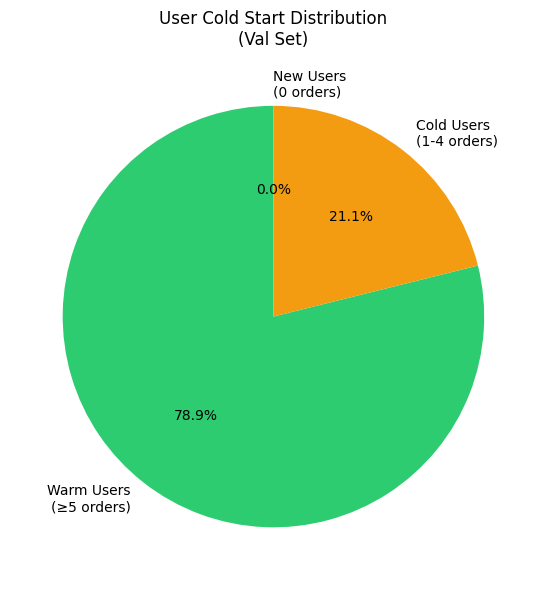


💡 Key Insight:
   21.1% of users need cold start handling


In [4]:
# Cell 4: Analyze cold start distribution
print("="*60)
print("COLD START ANALYSIS")
print("="*60)

# Check val users
val_users = val_df['user_id'].unique()
stats = handler.get_cold_start_stats(val_users)

# Visualize
labels = ['Warm Users\n(≥5 orders)', 'Cold Users\n(1-4 orders)', 'New Users\n(0 orders)']
sizes = [stats['warm'], stats['cold'], stats['new']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('User Cold Start Distribution\n(Val Set)')
plt.tight_layout()
plt.savefig('../notebooks/figures/cold_start_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Key Insight:")
print(f"   {stats['cold']/len(val_users):.1%} of users need cold start handling")

In [5]:
# Cell 5: Demo - New User Recommendations
print("="*60)
print("DEMO: NEW USER RECOMMENDATIONS")
print("="*60)

# Scenario 1: Brand new user, no info
print("\n📍 Scenario 1: Brand new user (no info)")
recs = handler.recommend_for_new_user(n=5)
print(recs[['product_name', 'score', 'reason']].to_string(index=False))

# Scenario 2: New user, knows they like produce
print("\n📍 Scenario 2: New user interested in produce (dept=4)")
recs_dept = handler.recommend_for_new_user(n=5, department_id=4)
print(recs_dept[['product_name', 'score', 'reason']].to_string(index=False))

# Scenario 3: New user, specific aisle (fresh fruits = aisle 24)
print("\n📍 Scenario 3: New user, fresh fruits aisle")
recs_aisle = handler.recommend_for_new_user(n=5, aisle_id=24)
print(recs_aisle[['product_name', 'score', 'reason']].to_string(index=False))

DEMO: NEW USER RECOMMENDATIONS

📍 Scenario 1: Brand new user (no info)
          product_name    score          reason
                Banana 1.000000 Overall popular
Bag of Organic Bananas 0.500000 Overall popular
  Organic Strawberries 0.333333 Overall popular
  Organic Baby Spinach 0.250000 Overall popular
  Organic Hass Avocado 0.200000 Overall popular

📍 Scenario 2: New user interested in produce (dept=4)
          product_name    score                  reason
                Banana 1.000000 Popular in department 4
Bag of Organic Bananas 0.500000 Popular in department 4
  Organic Strawberries 0.333333 Popular in department 4
  Organic Baby Spinach 0.250000 Popular in department 4
  Organic Hass Avocado 0.200000 Popular in department 4

📍 Scenario 3: New user, fresh fruits aisle
          product_name    score              reason
                Banana 1.000000 Popular in aisle 24
Bag of Organic Bananas 0.500000 Popular in aisle 24
  Organic Strawberries 0.333333 Popular in aisle 2

In [6]:
# Cell 6: Demo - Cold User Blending
print("="*60)
print("DEMO: COLD USER SCORE BLENDING")
print("="*60)

import joblib
lgbm_model = joblib.load('../models/saved/lgbm_baseline.pkl')

# Find a cold user (few orders)
cold_users = handler.user_order_counts[
    handler.user_order_counts['n_orders'] < 5
]['user_id'].values

if len(cold_users) > 0:
    sample_cold_user = cold_users[0]
    n_orders = handler.user_order_counts[
        handler.user_order_counts['user_id'] == sample_cold_user
    ]['n_orders'].values[0]
    
    print(f"\nSample cold user: {sample_cold_user} ({n_orders} orders)")
    
    # Get their products from val
    user_products = val_df[val_df['user_id'] == sample_cold_user]
    
    if len(user_products) > 0:
        # Model scores
        model_scores = lgbm_model.predict(user_products)
        product_ids = user_products['product_id'].values
        
        # Blended scores
        blended_scores, alpha_used = handler.blend_with_popularity(
            sample_cold_user,
            model_scores,
            product_ids
        )
        
        # Compare
        comparison = pd.DataFrame({
            'product_id': product_ids,
            'model_score': model_scores,
            'blended_score': blended_scores,
            'true_label': user_products['reordered'].values
        }).sort_values('blended_score', ascending=False)
        
        # Add product names
        comparison = comparison.merge(
            products[['product_id', 'product_name']],
            on='product_id',
            how='left'
        )
        
        print(f"Alpha used: {alpha_used} (model weight)")
        print(f"\nTop 10 recommendations (blended):")
        print(comparison.head(10)[
            ['product_name', 'model_score', 'blended_score', 'true_label']
        ].to_string(index=False))
else:
    print("No cold users in val set (all users have ≥5 orders)")
    print("This is expected - Instacart filtered users with <4 orders")
    print("Cold start handling would activate for NEW users in production")

DEMO: COLD USER SCORE BLENDING

Sample cold user: 5 (4 orders)


In [7]:
# Cell 7: Cold Start Summary
print("="*60)
print("COLD START STRATEGY SUMMARY")
print("="*60)

print("""
🎯 Problem:
   New or sparse users don't have enough history
   for collaborative filtering models to work well

📋 Our Strategy (3 tiers):

   Tier 1 - NEW USER (0 orders):
   → Return overall popular products
   → If category known: filter to department/aisle
   → Pure popularity-based scoring

   Tier 2 - COLD USER (1-4 orders):
   → Blend model score + popularity score
   → Alpha blending: score = α×model + (1-α)×popularity
   → α increases with order count (more history = trust model more)
   → 1 order: α=0.3, 3 orders: α=0.5, 5+ orders: α=0.7

   Tier 3 - WARM USER (5+ orders):
   → Pure model prediction
   → No popularity blending needed

🔧 Production Implementation:
   → Check user order count at request time
   → Route to appropriate strategy
   → Seamless fallback in API layer

📊 Instacart Dataset Note:
   → Dataset filtered users with <4 orders
   → 0 truly cold users in our val set
   → Cold start logic activates for production new users
""")

COLD START STRATEGY SUMMARY

🎯 Problem:
   New or sparse users don't have enough history
   for collaborative filtering models to work well

📋 Our Strategy (3 tiers):

   Tier 1 - NEW USER (0 orders):
   → Return overall popular products
   → If category known: filter to department/aisle
   → Pure popularity-based scoring

   Tier 2 - COLD USER (1-4 orders):
   → Blend model score + popularity score
   → Alpha blending: score = α×model + (1-α)×popularity
   → α increases with order count (more history = trust model more)
   → 1 order: α=0.3, 3 orders: α=0.5, 5+ orders: α=0.7

   Tier 3 - WARM USER (5+ orders):
   → Pure model prediction
   → No popularity blending needed

🔧 Production Implementation:
   → Check user order count at request time
   → Route to appropriate strategy
   → Seamless fallback in API layer

📊 Instacart Dataset Note:
   → Dataset filtered users with <4 orders
   → 0 truly cold users in our val set
   → Cold start logic activates for production new users

